# 01 – MIDI Exploration (Classical Piano / MAESTRO)
**Project**: [MIDI Music Generation](https://github.com/S33mi/midi-music-generation)  
**Author**: [S33mi](https://github.com/S33mi/)  

Explore the **MAESTRO** classical piano MIDI dataset, inspect note structure, and prepare intuition for sequence modeling in later notebooks.

Dataset: MAESTRO v2 MIDI-only (~56 MB) – standard for piano generation tutorials.

## 1. Setup & Imports


Run Once if needed
```
!pip install pretty_midi
# Optional
!pip install pretty_midi mido music21
```

In [7]:
# !pip install pretty_midi

In [8]:
# !pip install pretty_midi mido music21

In [30]:
import os
import glob
import pathlib
import shutil # added
import collections
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pretty_midi
import tensorflow as tf
from tqdm.auto import tqdm
import warnings


warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("TensorFlow:", tf.__version__)
print("pretty_midi ready.")

TensorFlow: 2.20.0
pretty_midi ready.


## 2. Download MAESTRO MIDI (Colab / local)


In [20]:
DATA_DIR = pathlib.Path("data/maestro-v2.0.0")
ZIP_NAME = "maestro-v2.0.0-midi.zip"
URL = "https://storage.googleapis.com/magentadata/datasets/maestro/v2.0.0/maestro-v2.0.0-midi.zip"

# Clean previous broken attempts
if DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)
if pathlib.Path("data").exists():
    # also remove the cached zip if present
    zip_path = pathlib.Path("data") / ZIP_NAME
    if zip_path.exists():
        zip_path.unlink()

print("Downloading MAESTRO MIDI (~56 MB) ...")
tf.keras.utils.get_file(
    fname=ZIP_NAME,
    origin=URL,
    extract=True,
    cache_dir=".",
    cache_subdir="data",
)
print("Download + extract done.")

# Check where files landed
print("\nAfter extract – contents of data/:")
!ls -la data/

# The zip usually extracts to data/maestro-v2.0.0/
# but sometimes the year folders end up directly under data/
if not DATA_DIR.exists():
    # Try the alternative structure
    possible = list(pathlib.Path("data").glob("**/2004"))
    if possible:
        print("Found year folders under:", possible[0].parent)
        DATA_DIR = possible[0].parent
    else:
        print("Still cannot locate maestro folder. Paste the output of the diagnostic cell above.")


# List MIDI files
filenames = sorted(glob.glob(str(DATA_DIR / "**" / "*.mid*"), recursive=True))
print(f"\nNumber of MIDI files: {len(filenames)}")
print("Example paths:")
for p in filenames[:5]:
    print(" ", p)

59243107/59243107 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Download + extract done.

After extract – contents of data/:
total 57868
drwxr-xr-x 3 root root     4096 Sep 30 10:40 .
drwxr-xr-x 1 root root     4096 Sep 30 10:37 ..
-rw-r--r-- 1 root root 59243107 Sep 30 10:40 maestro-v2.0.0-midi.zip
drwxr-xr-x 3 root root     4096 Sep 30 10:37 maestro-v2_extracted
Found year folders under: data/maestro-v2_extracted/maestro-v2.0.0

Number of MIDI files: 1282
Example paths:
  data/maestro-v2_extracted/maestro-v2.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_05_Track05_wav.midi
  data/maestro-v2_extracted/maestro-v2.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_06_Track06_wav.midi
  data/maestro-v2_extracted/maestro-v2.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.midi
  data/maestro-v2_extracted/maestro-v2.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.midi
  da

## 3. Inspect a Single MIDI File


In [21]:
sample_file = filenames[0]
print("Sample file:", sample_file)

pm = pretty_midi.PrettyMIDI(sample_file)

print("\n--- Basic info ---")
print(f"Duration (s)     : {pm.get_end_time():.1f}")
print(f"Instruments      : {len(pm.instruments)}")
for i, inst in enumerate(pm.instruments):
    print(f"  [{i}] program={inst.program}, is_drum={inst.is_drum}, name={inst.name!r}, notes={len(inst.notes)}")

# Use first non-drum instrument
piano = None
for inst in pm.instruments:
    if not inst.is_drum:
        piano = inst
        break

if piano is None:
    raise RuntimeError("No non-drum instrument found in sample file.")

print(f"\nUsing instrument: program={piano.program}, notes={len(piano.notes)}")

Sample file: data/maestro-v2_extracted/maestro-v2.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_05_Track05_wav.midi

--- Basic info ---
Duration (s)     : 969.0
Instruments      : 1
  [0] program=0, is_drum=False, name='', notes=7894

Using instrument: program=0, notes=7894


### First few notes


In [22]:
notes_preview = []
for n in piano.notes[:15]:
    notes_preview.append({
        "pitch": n.pitch,
        "pitch_name": pretty_midi.note_number_to_name(n.pitch),
        "start": round(n.start, 3),
        "end": round(n.end, 3),
        "duration": round(n.end - n.start, 3),
        "velocity": n.velocity,
    })

pd.DataFrame(notes_preview)

,pitch,pitch_name,start,end,duration,velocity
0,71,B4,1.093,1.190,0.097,60
1,55,G3,1.279,1.497,0.218,44
2,59,B3,1.464,1.631,0.168,55
3,62,D4,1.633,1.753,0.120,52
4,71,B4,1.289,1.794,0.505,54
5,72,C5,1.786,1.828,0.042,76
6,67,G4,1.803,2.000,0.197,56
7,74,D5,1.983,2.098,0.115,68
8,72,C5,2.038,2.106,0.069,77
9,74,D5,2.098,2.182,0.084,51


## 4. Helper: Extract Note Arrays from a MIDI File


In [23]:
def midi_to_notes(midi_file: str) -> pd.DataFrame:
    """Extract pitch, start, end, duration, velocity from the first non-drum instrument."""
    pm = pretty_midi.PrettyMIDI(midi_file)
    instrument = None
    for inst in pm.instruments:
        if not inst.is_drum and len(inst.notes) > 0:
            instrument = inst
            break
    if instrument is None:
        return pd.DataFrame(columns=["pitch", "start", "end", "duration", "velocity"])

    notes = collections.defaultdict(list)
    sorted_notes = sorted(instrument.notes, key=lambda n: n.start)
    prev_start = sorted_notes[0].start if sorted_notes else 0.0

    for note in sorted_notes:
        start = note.start
        end = note.end
        notes["pitch"].append(note.pitch)
        notes["start"].append(start)
        notes["end"].append(end)
        notes["duration"].append(end - start)
        notes["velocity"].append(note.velocity)
        notes["step"].append(start - prev_start)  # time since previous note onset
        prev_start = start

    return pd.DataFrame(notes)

raw_notes = midi_to_notes(sample_file)
print(f"Notes in sample: {len(raw_notes)}")
raw_notes.head(10)

Notes in sample: 7894


,pitch,start,end,duration,velocity,step
0,71,1.092708,1.189583,0.096875,60,0.000000
1,55,1.279167,1.496875,0.217708,44,0.186458
2,71,1.288542,1.793750,0.505208,54,0.009375
3,59,1.463542,1.631250,0.167708,55,0.175000
4,62,1.633333,1.753125,0.119792,52,0.169792
5,72,1.786458,1.828125,0.041667,76,0.153125
6,67,1.803125,2.000000,0.196875,56,0.016667
7,74,1.983333,2.097917,0.114583,68,0.180208
8,57,1.983333,2.522917,0.539583,61,0.000000
9,72,2.037500,2.106250,0.068750,77,0.054167


## 5. Visualize a Short Excerpt

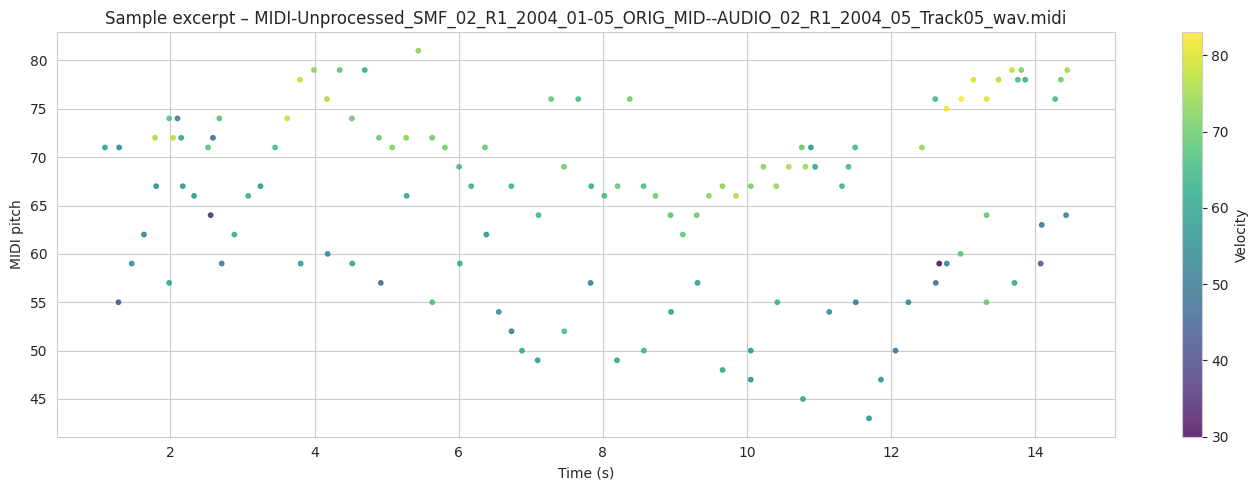

In [24]:
def plot_piano_roll(notes_df: pd.DataFrame, count: int = 100, title: str = "Piano roll"):
    """Simple pitch vs time scatter (piano-roll style)."""
    subset = notes_df.head(count)
    plt.figure(figsize=(14, 5))
    plt.scatter(subset["start"], subset["pitch"], s=10, c=subset["velocity"], cmap="viridis", alpha=0.8)
    plt.xlabel("Time (s)")
    plt.ylabel("MIDI pitch")
    plt.title(title)
    plt.colorbar(label="Velocity")
    plt.tight_layout()
    plt.show()

plot_piano_roll(raw_notes, count=120, title=f"Sample excerpt – {pathlib.Path(sample_file).name}")

## 6. Dataset-level Statistics (sample of files)

In [25]:
# Use a subset for speed (full pass is fine too, just slower)
N_SAMPLE = min(80, len(filenames))
sample_files = filenames[:N_SAMPLE]

stats = []
all_pitches = []
all_durations = []
all_steps = []

for f in tqdm(sample_files, desc="Scanning MIDI files"):
    try:
        notes = midi_to_notes(f)
        if len(notes) == 0:
            continue
        stats.append({
            "file": pathlib.Path(f).name,
            "n_notes": len(notes),
            "duration_s": notes["end"].max(),
            "pitch_min": notes["pitch"].min(),
            "pitch_max": notes["pitch"].max(),
            "pitch_mean": notes["pitch"].mean(),
            "vel_mean": notes["velocity"].mean(),
        })
        all_pitches.extend(notes["pitch"].tolist())
        all_durations.extend(notes["duration"].tolist())
        all_steps.extend(notes["step"].tolist())
    except Exception as e:
        print(f"Skip {f}: {e}")

stats_df = pd.DataFrame(stats)
print(f"Successfully parsed: {len(stats_df)} files")
display(stats_df.describe().round(2))


Scanning MIDI files:   0%|          | 0/80 [00:00<?, ?it/s]

Successfully parsed: 80 files


,n_notes,duration_s,pitch_min,pitch_max,pitch_mean,vel_mean
count,80.00,80.00,80.00,80.00,80.00,80.00
mean,6251.65,633.57,26.51,97.56,64.00,63.75
std,4654.33,447.19,4.32,7.43,2.93,6.75
min,931.00,130.58,21.00,77.00,53.24,41.65
25%,2838.25,300.37,24.00,93.75,62.42,60.72
50%,5182.50,537.84,25.00,101.00,64.05,64.95
75%,7911.25,774.19,29.00,103.00,66.03,69.03
max,19689.00,2398.54,38.00,108.00,71.03,78.21


### Pitch distribution

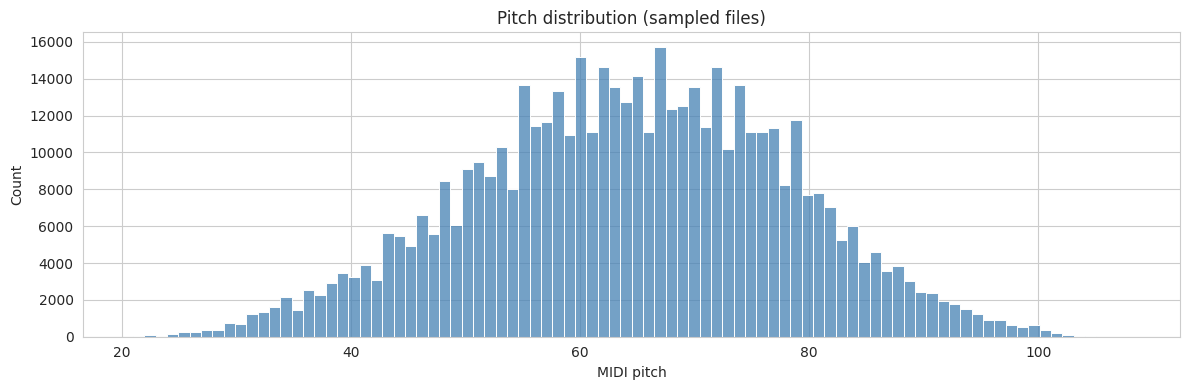

Pitch range: 21 – 108
Most common pitches: [(67, 15732), (60, 15174), (62, 14660), (72, 14613), (65, 14144), (55, 13685), (74, 13667), (63, 13568)]


In [26]:
plt.figure(figsize=(12, 4))
sns.histplot(all_pitches, bins=88, color="steelblue")
plt.xlabel("MIDI pitch")
plt.ylabel("Count")
plt.title("Pitch distribution (sampled files)")
plt.tight_layout()
plt.show()

print(f"Pitch range: {min(all_pitches)} – {max(all_pitches)}")
print(f"Most common pitches: {Counter(all_pitches).most_common(8)}")

### Duration & step distributions

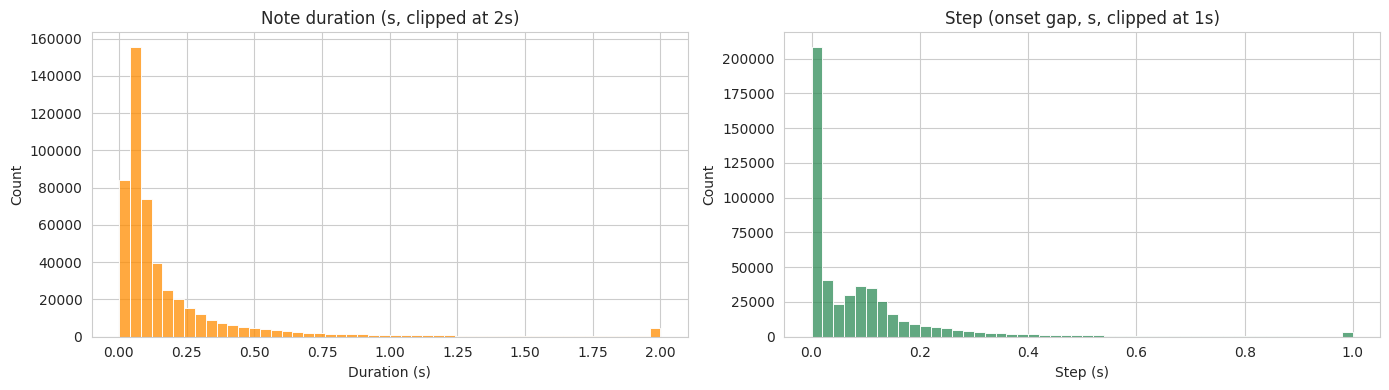

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Cap outliers for readable plots
dur_clip = np.clip(all_durations, 0, 2.0)
step_clip = np.clip(all_steps, 0, 1.0)

sns.histplot(dur_clip, bins=50, ax=axes[0], color="darkorange")
axes[0].set_title("Note duration (s, clipped at 2s)")
axes[0].set_xlabel("Duration (s)")

sns.histplot(step_clip, bins=50, ax=axes[1], color="seagreen")
axes[1].set_title("Step (onset gap, s, clipped at 1s)")
axes[1].set_xlabel("Step (s)")

plt.tight_layout()
plt.show()

## 7. What We Will Model Later

For the LSTM we typically predict, for each note:

| Feature | Meaning |
|---------|---------|
| **pitch** | MIDI note number (0–127) |
| **step** | Time since previous note onset |
| **duration** | How long the note is held |

Velocity can be included or fixed for simplicity.

Next notebooks will:
1. Encode these into fixed-length sequences  
2. Train an LSTM to predict the next `(pitch, step, duration)`  
3. Sample new sequences and write them back to MIDI  

## 8. Quick Summary

In [28]:
print("=== Summary ===")
print(f"MIDI files found     : {len(filenames)}")
print(f"Files scanned        : {len(stats_df)}")
print(f"Total notes (sample) : {len(all_pitches)}")
print(f"Avg notes / file     : {stats_df['n_notes'].mean():.0f}")
print(f"Avg duration (s)     : {stats_df['duration_s'].mean():.1f}")
print(f"Pitch range          : {min(all_pitches)} – {max(all_pitches)}")
print("\nReady for preprocessing → training → generation.")

=== Summary ===
MIDI files found     : 1282
Files scanned        : 80
Total notes (sample) : 500132
Avg notes / file     : 6252
Avg duration (s)     : 633.6
Pitch range          : 21 – 108

Ready for preprocessing → training → generation.
